<a href="https://colab.research.google.com/github/bhuvaneshwari-99/License_Plate_Validation/blob/main/week03.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

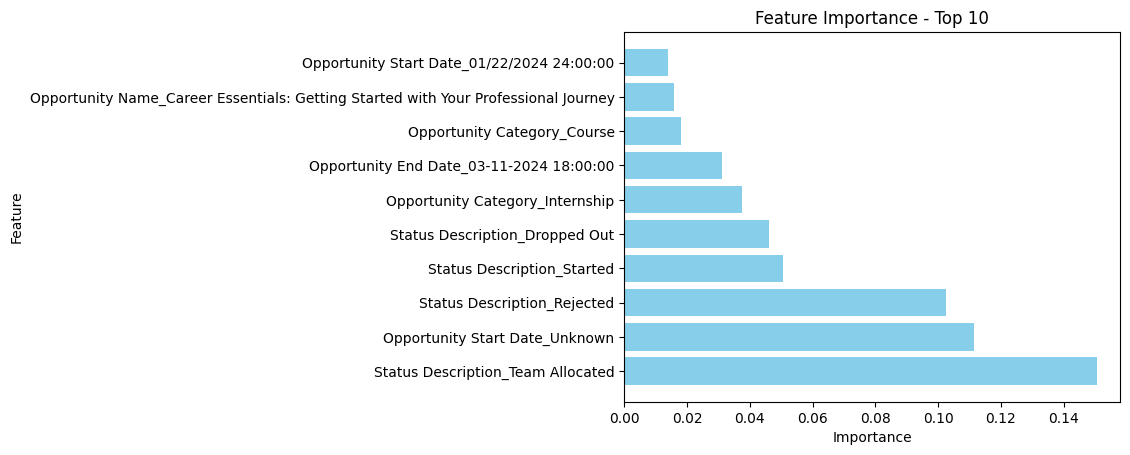

Saving student_dropoff.csv to student_dropoff (7).csv
Dataset Loaded Successfully
  ï»¿Learner SignUp DateTime                  Opportunity Id  \
0        06/14/2023 12:30:35  00000000-0GN2-A0AY-7XK8-C5FZPP   
1        05-01-2023 05:29:16  00000000-0GN2-A0AY-7XK8-C5FZPP   
2        04-09-2023 20:35:08  00000000-0GN2-A0AY-7XK8-C5FZPP   
3        08/29/2023 05:20:03  00000000-0GN2-A0AY-7XK8-C5FZPP   
4        01-06-2023 15:26:36  00000000-0GN2-A0AY-7XK8-C5FZPP   

                                    Opportunity Name Opportunity Category  \
0  Career Essentials: Getting Started with Your P...               Course   
1  Career Essentials: Getting Started with Your P...               Course   
2  Career Essentials: Getting Started with Your P...               Course   
3  Career Essentials: Getting Started with Your P...               Course   
4  Career Essentials: Getting Started with Your P...               Course   

  Opportunity End Date        First Name Date of Birth  Gender        

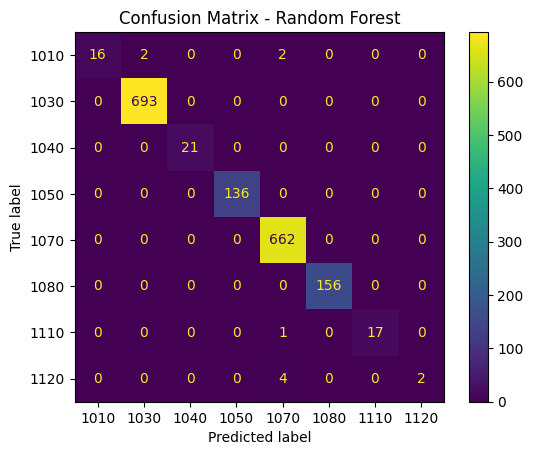


Feature Importance:
                                 Feature  Importance
12287  Status Description_Team Allocated    0.150495
20854     Opportunity Start Date_Unknown    0.111451
12284        Status Description_Rejected    0.102535
12286         Status Description_Started    0.050534
12283     Status Description_Dropped Out    0.046232
...                                  ...         ...
5123                  First Name_Kshitij    0.000000
5081            First Name_Khair Un Nisa    0.000000
5082                   First Name_Khalid    0.000000
5090               First Name_Khushi Raj    0.000000
5044                 First Name_Karishma    0.000000

[20855 rows x 2 columns]


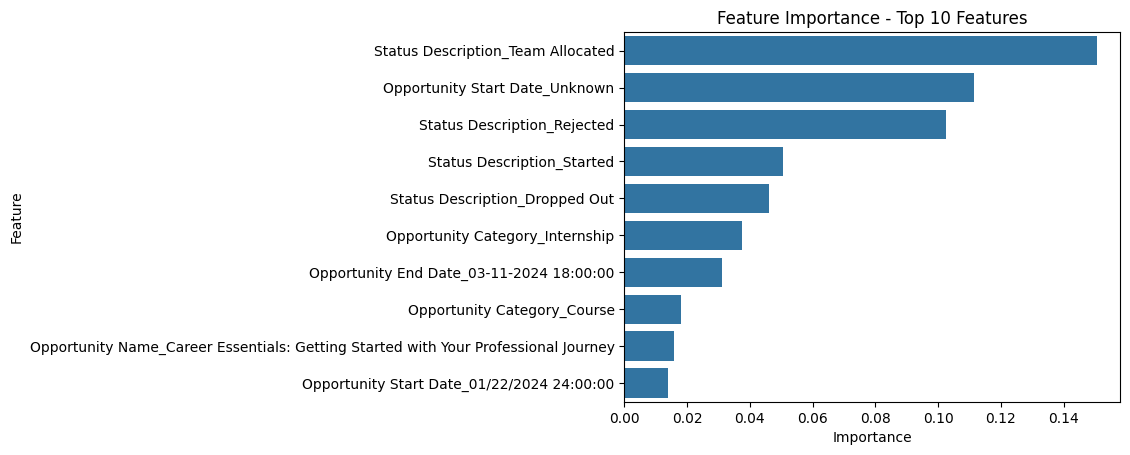

In [ ]:
# Install necessary libraries
!pip install seaborn matplotlib scikit-learn

# Import Libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, ConfusionMatrixDisplay
from sklearn.model_selection import GridSearchCV
import pickle
import matplotlib.pyplot as plt
from matplotlib import rcParams
import matplotlib.pyplot as plt
from matplotlib import rcParams
import warnings
# Simplified Matplotlib bar plot for feature importance
top_features = feature_importance.head(10)  # Top 10 features
plt.barh(top_features['Feature'], top_features['Importance'], color='skyblue')
plt.title("Feature Importance - Top 10")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

# Suppress font-related warnings globally in Colab
warnings.filterwarnings("ignore", category=UserWarning)

# Configure Matplotlib settings (optional font change for Unicode compatibility)
rcParams['font.family'] = 'DejaVu Sans'

# Configure Matplotlib font settings
rcParams['font.family'] = 'Noto Sans'  # Change to 'Arial Unicode MS' if preferred
# Optionally suppress font-related warnings
import warnings
warnings.filterwarnings("ignore", category=UserWarning)
# Configure Matplotlib
from matplotlib import rcParams
rcParams['font.family'] = 'DejaVu Sans'

from google.colab import files

# Upload the file from your local machine
uploaded = files.upload()

# Read the uploaded file
file_name = next(iter(uploaded.keys()))  # Automatically retrieves the file name
data = pd.read_csv(file_name, encoding='latin1', on_bad_lines='skip')
print("Dataset Loaded Successfully")
print(data.head())

import chardet

# Detect encoding
with open(file_name, 'rb') as file:
    result = chardet.detect(file.read())
    encoding = result['encoding']
    print(f"Detected Encoding: {encoding}")

# Load the file using the detected encoding
data = pd.read_csv(file_name, encoding=encoding, on_bad_lines='skip')
print("Dataset Loaded Successfully")
print(data.head())
data = pd.read_csv(file_name, encoding='latin1', on_bad_lines='skip')
print("CSV File Loaded Successfully")
print(data.head())
with open(file_name, 'r', encoding='latin1') as file:
    for _ in range(5):  # Preview the first 5 lines
        print(file.readline())

# Clean and Prepare Data
# Handling missing values
numeric_columns = data.select_dtypes(include=['number'])
data[numeric_columns.columns] = data[numeric_columns.columns].fillna(numeric_columns.mean())

categorical_columns = data.select_dtypes(include=['object'])
data[categorical_columns.columns] = data[categorical_columns.columns].fillna("Unknown")

# Remove duplicates
data = data.drop_duplicates()
print("Data shape after cleaning:", data.shape)

# Encode categorical features
data = pd.get_dummies(data, drop_first=True)

# Define Features (X) and Target (y)
if "Status Code" in data.columns:  # Replace with your actual target column
    X = data.drop("Status Code", axis=1)
    y = data["Status Code"]
else:
    raise ValueError("Target column 'status_code' not found in dataset")
print(data.columns)
print(data.head())
# Split Data into Training and Testing Sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# Train Logistic Regression Model
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train, y_train)
log_reg_pred = log_reg.predict(X_test)

print("\nLogistic Regression Performance:")
print("Accuracy:", accuracy_score(y_test, log_reg_pred))
print("Precision:", precision_score(y_test, log_reg_pred, average='macro'))
print("Recall:", recall_score(y_test, log_reg_pred, average='macro'))
print("F1 Score:", f1_score(y_test, log_reg_pred, average='macro'))

# Train Decision Tree Model
decision_tree = DecisionTreeClassifier(random_state=42)
decision_tree.fit(X_train, y_train)
tree_pred = decision_tree.predict(X_test)

print("\nDecision Tree Performance:")
print("Accuracy:", accuracy_score(y_test, tree_pred))
print("Precision:", precision_score(y_test, tree_pred, average='macro'))
print("Recall:", recall_score(y_test, tree_pred, average='macro'))
print("F1 Score:", f1_score(y_test, tree_pred, average='macro'))

# Train Random Forest Model
random_forest = RandomForestClassifier(n_estimators=100, random_state=42)
random_forest.fit(X_train, y_train)
forest_pred = random_forest.predict(X_test)

print("\nRandom Forest Performance:")
print("Accuracy:", accuracy_score(y_test, forest_pred))
print("Precision:", precision_score(y_test, forest_pred, average='macro'))
print("Recall:", recall_score(y_test, forest_pred, average='macro'))
print("F1 Score:", f1_score(y_test, forest_pred, average='macro'))
# Confusion Matrix for Random Forest
ConfusionMatrixDisplay.from_estimator(random_forest, X_test, y_test)
plt.title("Confusion Matrix - Random Forest")
plt.show()

# Feature Importance (Random Forest)
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': random_forest.feature_importances_
})
feature_importance = feature_importance.sort_values(by='Importance', ascending=False)
print("\nFeature Importance:")
print(feature_importance)
# Limit to top 10 features for faster rendering in Colab
sns.barplot(x='Importance', y='Feature', data=feature_importance.head(10))
plt.title("Feature Importance - Top 10 Features")
plt.show()
# Hyperparameter Tuning with GridSearchCV
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10]
}
grid_search = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=5, scoring='f1_macro')
grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)

# Evaluate Optimized Model
optimized_rf = grid_search.best_estimator_
optimized_rf.fit(X_train, y_train)
optimized_pred = optimized_rf.predict(X_test)

print("\nOptimized Random Forest Performance:")
print("Accuracy:", accuracy_score(y_test, optimized_pred))
print("Precision:", precision_score(y_test, optimized_pred, average='macro'))
print("Recall:", recall_score(y_test, optimized_pred, average='macro'))
print("F1 Score:", f1_score(y_test, optimized_pred, average='macro'))
# Save the Optimized Model
with open('optimized_student_dropoff_model.pkl', 'wb') as file:
    pickle.dump(optimized_rf, file)
print("Optimized model saved successfully.")

